# Explore here

In [2]:
#LIBRERÍAS A UTILIZAR

import pandas as pd


In [27]:
df = pd.read_csv('https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv', sep=';')
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [28]:
df.shape

(41188, 21)

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [30]:
categoricas = df.select_dtypes(include=['str']).columns.tolist() # Esta función sirve para obtener las columnas de algún tipo

categoricas

# Y así obtenemos las que son de tipo 'str'

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome',
 'y']

In [31]:
# Y para obtener las numéricas es un proceso casi igual:

numericas = df.select_dtypes(exclude=['str']).columns.tolist()

numericas

['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

In [32]:
# Antes de empezar a tocar estas columnas y empezar a trabajar en ellas, lo primero que tenemos que hacer es ver si hay duplicados:

df.duplicated().sum()

np.int64(12)

In [33]:
# si tenemos filas duplicadas entonces:

if df.duplicated().sum():
    df.drop_duplicates(inplace= True)

df.shape

# Con esto, quitamos las 12 duplicadas.

(41176, 21)

In [34]:
# Vamos a hacer un FOR para transformar variables categóricas en numéricas:

for columna in categoricas:
    df[columna] = pd.factorize(df[columna])[0]

df.info()

# Y todas se transforman en numéricas.

<class 'pandas.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  int64  
 2   marital         41176 non-null  int64  
 3   education       41176 non-null  int64  
 4   default         41176 non-null  int64  
 5   housing         41176 non-null  int64  
 6   loan            41176 non-null  int64  
 7   contact         41176 non-null  int64  
 8   month           41176 non-null  int64  
 9   day_of_week     41176 non-null  int64  
 10  duration        41176 non-null  int64  
 11  campaign        41176 non-null  int64  
 12  pdays           41176 non-null  int64  
 13  previous        41176 non-null  int64  
 14  poutcome        41176 non-null  int64  
 15  emp.var.rate    41176 non-null  float64
 16  cons.price.idx  41176 non-null  float64
 17  cons.conf.idx   41176 non-null  float64
 18  eu

In [35]:
df.head()

# El NO quedó como 0, y el SÍ quedó como 1. Tenemos 20 predictoras, es un modelo grande en sí, pero no necesariamente todas las columnas van a servir, y eso lo vemos con un EDA. 

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,0,0,0,0,0,0,0,0,0,...,1,999,0,0,1.1,93.994,-36.4,4.857,5191.0,0
1,57,1,0,1,1,0,0,0,0,0,...,1,999,0,0,1.1,93.994,-36.4,4.857,5191.0,0
2,37,1,0,1,0,1,0,0,0,0,...,1,999,0,0,1.1,93.994,-36.4,4.857,5191.0,0
3,40,2,0,2,0,0,0,0,0,0,...,1,999,0,0,1.1,93.994,-36.4,4.857,5191.0,0
4,56,1,0,1,0,0,1,0,0,0,...,1,999,0,0,1.1,93.994,-36.4,4.857,5191.0,0


# AQUÍ VA EL EDA (HACERLO SOLITOS)

El fin es crear un algoritmo de clasificación que ayude a **predecir si un cliente contratará o no un depósito a largo plazo**.

Variable objetivo: 'y'


## 1. Eliminar información irrelevante:

**Debemos responder a la siguiente pregunta: ¿son todas las características imprescindibles para realizar una predicción? Normalmente, esa pregunta es un rotundo no.**

En este caso en particular, considero que todas las variables son dignas de analizarse, porque todas están relacionadas con el problema. No existen índices ni nombres, ni ID, que no tengan que ver con un préstamo o con el contacto del cliente, por ende no descartaremos ninguna.

## 2. Eliminamos duplicados: 
A este paso lo realizamos con anterioridad. 

## 3. Análisis de variables univariante:

Esto es el análisis columna a columna del DataFrame. Para ello, debemos distinguir si una variable es categórica o numérica, ya que el análisis y las conclusiones que se pueden obtener serán distintas.

In [19]:
numericas = ['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']


categoricas = ['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome',
 'y']


Análisis de variables CATEGÓRICAS:

Para representar este tipo de variables utilizaremos histogramas o gráficos de barras verticales.

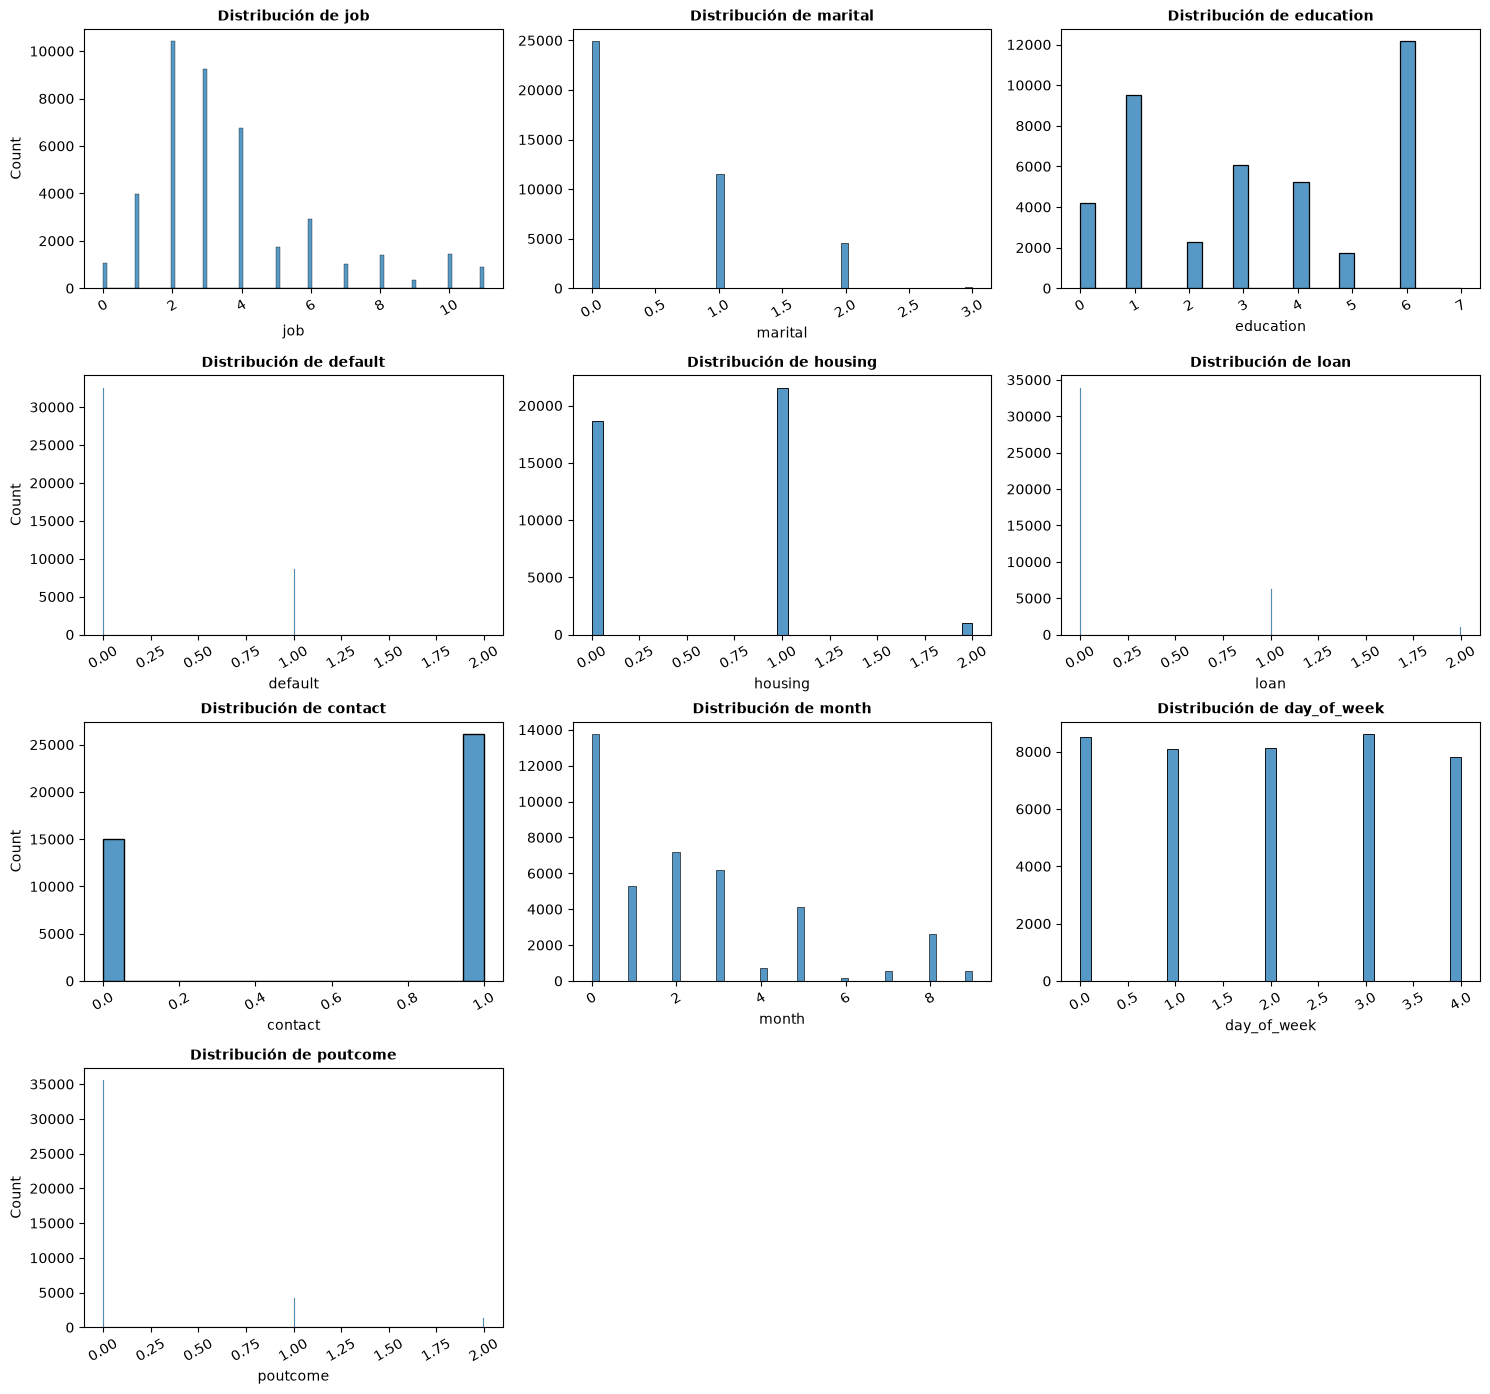

In [18]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de la retícula: 3 columnas
ncols = 3
num_vars = len(categoricas)
nrows = math.ceil(num_vars / ncols)  # Dará 4 filas (4x3 = 12 espacios)

fig, axis = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 14))

# Bucle para graficar automáticamente cada variable de la lista
for i, col in enumerate(categoricas):
    row = i // ncols
    c = i % ncols
    ax = axis[row, c]
    
    # Crear histograma para cada variable
    sns.histplot(ax=ax, data=df, x=col)
    ax.set_title(f'Distribución de {col}', fontsize=10, fontweight='bold')
    
    # Rotar las etiquetas del eje X si tienen nombres largos para evitar solapamiento
    ax.tick_params(axis='x', rotation=30)
    
    # Opcional: eliminar la etiqueta repetitiva de 'Count' salvo en la primera columna
    if c != 0:
        ax.set(ylabel=None)

# Ocultar los subgráficos sobrantes (las celdas 11 y 12 que quedan vacías)
for j in range(num_vars, nrows * ncols):
    row = j // ncols
    c = j % ncols
    fig.delaxes(axis[row, c])

plt.tight_layout()
plt.show()

**Conclusiones de las variables categóricas según sus distribuciones en los gráficos:**

job (Ocupación): Gran concentración laboral. Tres perfiles resumen casi todo el volumen: administrativos (admin.), operarios (blue-collar) y técnicos. Sectores como estudiantes o jubilados son testimoniales.

marital (Estado Civil): Dominio absoluto de personas casadas (married), representando más del 50% de la base total. Los solteros son el segundo grupo en relevancia y los divorciados una minoría.

education (Nivel Educativo): Perfil educativo medio-alto. La mayoría posee título universitario o secundaria completa. Los niveles de educación primaria básica representan una porción pequeña del total.

default (Crédito en Mora): Variable sin varianza útil. La inmensa mayoría casi absoluta es no y el resto son valores no informados (unknown). Prácticamente no existen registros confirmados de clientes en mora (yes).

housing (Préstamo Hipotecario): Distribución equilibrada. La muestra se divide casi en partes iguales (50/50) entre quienes tienen una hipoteca activa y quienes no.

loan (Préstamo Personal): Baja penetración. Al contrario de la vivienda, la gran mayoría de los clientes no posee préstamos personales vigentes.

contact (Medio de Contacto): Preferencia por la telefonía móvil. Las llamadas a teléfono celular superan sustancialmente a las realizadas a teléfonos fijos tradicionales.

month (Mes de Contacto): Fuerte estacionalidad en la operativa. Mayo (may) concentra un pico masivo de llamadas, seguido por el período estival. Los meses de primavera/otoño registran muy pocos contactos.

day_of_week (Día de la Semana): Distribución completamente uniforme. La carga de contactos se reparte de forma homogénea (~20% diario) entre los cinco días laborables (lunes a viernes).

poutcome (Resultado de Campaña Anterior): Predominio de clientes nuevos. Domina abrumadoramente la categoría nonexistent, lo que indica que para la gran mayoría de la base es el primer contacto comercial y no existen antecedentes de campañas pasadas.


**Podemos decir que variables como 'default' y 'day_of_week' no aportarían información relevante a nuestro modelo predictivo ya que prácticamente no existen registros confirmados de clientes en mora, y por otro lado, la distribución de las llamadas en los días de la semana es uniforme (de Lunes a Viernes), es decir, los contactos a clientes se reparten homogéneamente en los 5 días hábiles de la semana.**

Análisis de variables NUMÉRICAS:

Normalmente se representan utilizando un histograma y diagramas de caja, expuestos juntos.

In [ ]:
numericas = ['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

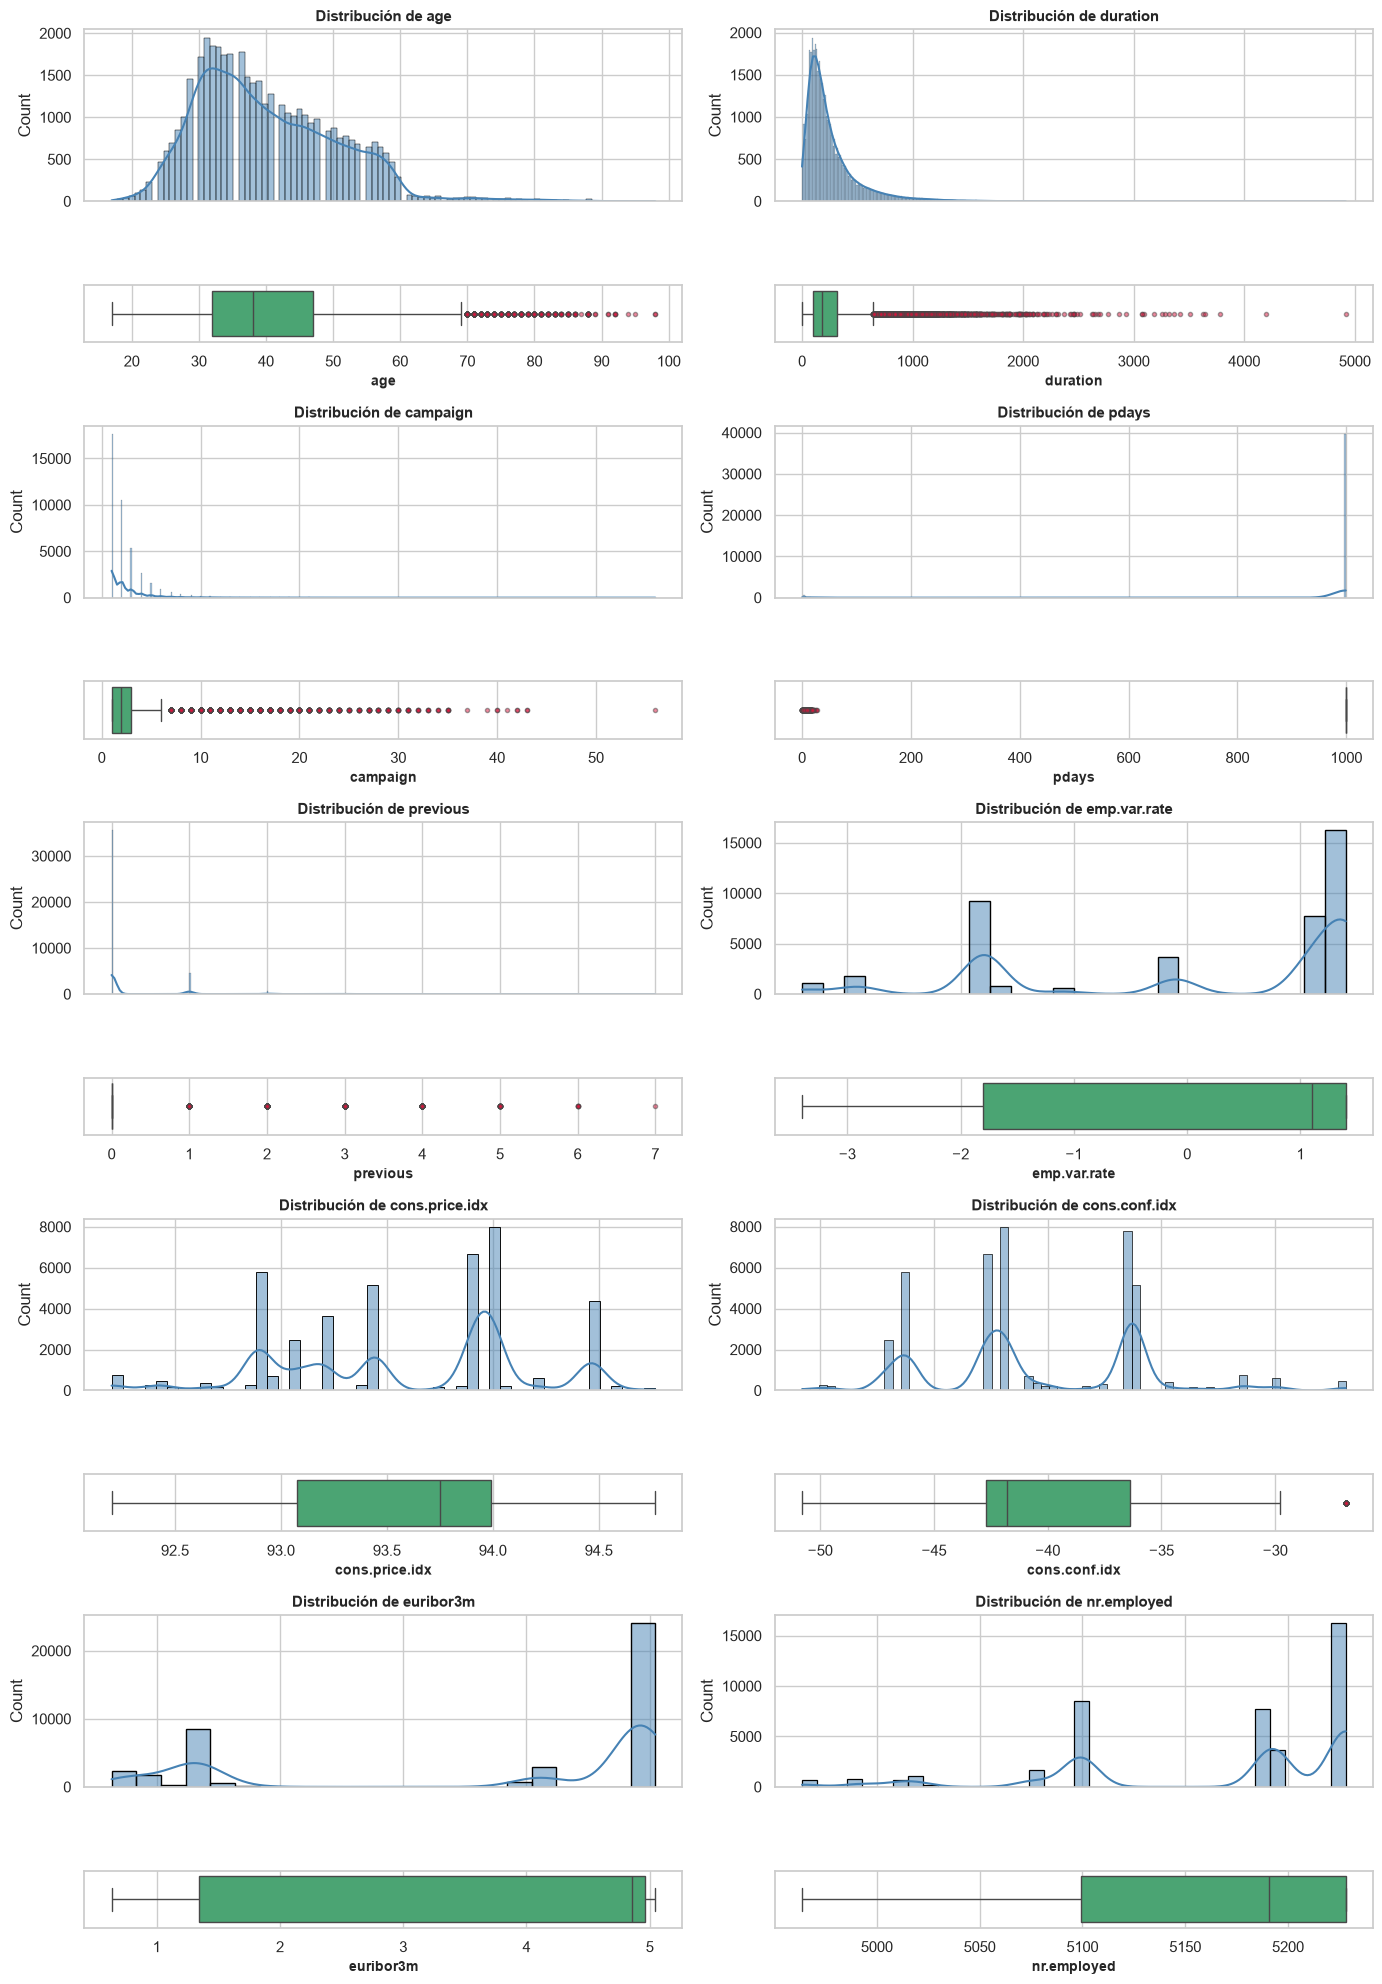

In [40]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Configuración de la retícula: 2 columnas x 5 bloques de variables
ncols = 2
num_vars = len(numericas)
num_bloques = math.ceil(num_vars / ncols)  # 5 bloques verticales

# Se crean 10 filas en total (2 filas por cada variable: 1 Histograma + 1 Boxplot)
fig, axes = plt.subplots(
    nrows=num_bloques * 2, 
    ncols=ncols, 
    figsize=(14, 4 * num_bloques), 
    gridspec_kw={'height_ratios': [3, 1] * num_bloques} # El histograma es más alto que el boxplot
)

# Bucle para graficar histograma + boxplot por cada variable
for i, col in enumerate(numericas):
    row_hist = (i // ncols) * 2  # Fila para el histograma
    c = i % ncols               # Columna (0 o 1)
    row_box = row_hist + 1       # Fila inmediatamente inferior para el boxplot
    
    ax_hist = axes[row_hist, c]
    ax_box = axes[row_box, c]
    
    # 1. Histograma (Arriba)
    sns.histplot(
        data=df, x=col, kde=True, ax=ax_hist, 
        color='steelblue', edgecolor='black'
    )
    ax_hist.set_title(f'Distribución de {col}', fontsize=11, fontweight='bold')
    ax_hist.set_xlabel('')
    ax_hist.tick_params(labelbottom=False)  # Oculta etiquetas numéricas repetidas en X
    
    # 2. Diagrama de caja / Boxplot (Abajo)
    sns.boxplot(
        data=df, x=col, ax=ax_box, color='mediumseagreen',
        flierprops=dict(marker='o', markerfacecolor='crimson', markersize=3, alpha=0.5)
    )
    ax_box.set_xlabel(col, fontsize=10, fontweight='bold')
    
    # Compartir el mismo eje X para asegurar alineación visual perfecta
    ax_hist.sharex(ax_box)

plt.tight_layout()
plt.show()

**Conclusiones de las variables Numéricas según sus distribuciones en los gráficos presentados:**

age: Concentrada entre 30 y 50 años (la media está entre 38 y 40 años), con atípicos en adultos mayores (>60 años).

duration: Sesgada a la derecha; llamadas cortas en su gran mayoría con atípicos aislados muy largos.

campaign: Casi todos reciben de 1 a 3 contactos, pero hay atípicos de persistencia extrema (>10) (demasiada insistencia).

pdays: Bimodal extrema; concentrada en 999 (sin contacto previo en campañas anteriores).

previous: Domina el 0; casi no hay registros con múltiples contactos previos.

emp.var.rate: Distribución bimodal dividida entre períodos de destrucción y creación de empleo.

cons.price.idx: Agrupada en bloques discretos correspondientes a distintos niveles de inflación.

cons.conf.idx: Distribución simétrica en valores negativos (confianza del consumidor baja/moderada).

euribor3m: Bimodal muy marcada; los datos se dividen entre tasas muy bajas (~1.2%) y altas (~4.8%).

nr.employed: Agrupada en niveles altos (>5000 empleados), reflejando la plantilla laboral en el tiempo.

**Podemos identificar dos variables que podríamos descartar: 'pdays' (ya que casi el 100% de los datos se agrupan en el valor numérico codificado 999) y 'emp.var.rate' (o en su defecto 'euribor3m') ya que tienen una correlación lineal extremadamente alta, y medir la variación del empleo y la tasa Euribor simultáneamente introduce multicolinealidad severa en modelos probabilísticos y lineales. Se recomienda conservar euribor3m (que suele tener mayor fuerza explicativa del entorno económico) y descartar 'emp.var.rate'.**

## 4. Análisis de variables multivariante. Análisis numérico-numérico.
Tras analizar las características una a una, es momento de analizarlas en relación con la predictora y con ellas mismas, para sacar conclusiones más claras acerca de sus relaciones y poder tomar decisiones sobre su procesamiento.

Para comparar dos columnas numéricas se utilizan diagramas de dispersión y análisis de correlaciones.

Pero antes vamos a realizar una Matríz de correlación, ya que esta es una tabla que muestra los coeficientes de correlación entre varias variables numéricas al mismo tiempo. 
Cada celda de la tabla te indica qué tan fuertemente se relacionan dos variables entre sí:

1.0: Correlación positiva perfecta (si una sube, la otra también sube en la misma proporción).

0.0: Sin relación lineal.

-1.0: Correlación negativa perfecta (si una sube, la otra baja).

In [ ]:
# Antes del modelo, tengo que definir mis x de train y de test:

x = df.drop(columns=['y'])
y= df['y']

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42 )

In [ ]:
# Tenemos que hacer la normalización de los datos (chequear si usamos el "standar" si sé que mis datos distribuyen normal, si no lo sé, voy a usar minmax) Asique en este caso lo vamos a hacer con minmax porque todavía no hacemos el Eda y estamos como ciegos. Luego que de que hagan el EDa pueden tomar una mejor decisión.

from sklearn.preprocessing import MinMaxScaler

scaler= MinMaxScaler()

x_train_esc = scaler.fit_transform(x_train)

x_train_esc = pd.DataFrame(x_train_esc, columns= x_train.columns, index= x_train.index)

x_test_esc = scaler.transform(x_test)

x_test_esc = pd.DataFrame(x_test_esc, columns =x_test.columns, index= x_test.index)




In [ ]:
x_train_esc.head() # para que los podamos ver. Y ahí ya están escalados los datos.

In [ ]:
# Una vez que todas las columnas son numéricas y están escaladas, podemos pensar en hacer una REGRESIÓN LOGÍSTICA:

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(x_train_esc, y_train)

# Y tenemos todos los hiperparámetros que está utilizando el modelo por defecto. Y tmb podemos ver los atributos del modelo, que es lo que usó para hacer las predicciones.

In [ ]:
# Hasta acá ya tengo un modelo entrenado sobre mis x de entrenamiento (x_train). 
# Ahora lo que necesito son resultados. 

y_pred = model.predict(x_test_esc)
y_pred

# ¿Cómo se va an a ver? En este caso es un Array de 8.236 de largo, que es el 20% + o - de los 41 mil casos que tengo, y voy a ver un conjunto de unos y ceros. Esto sólo me dice que ya el modelo hizo predicciones. 

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

# Acá comparamos los y de test con los y predichos. 
# y nos dice que este modelo (sin el EDA realizado todavía) tiene un 90.23 % de probabilidad de acertar. Si yo ahora analizo un nuevo cliente, mi modelo va a ser capaz de predecir en un 90% si ese cliente va a tomar o no va a tomar un crédito. 

In [ ]:
# Matríz de confusión

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp= ConfusionMatrixDisplay (cm, display_labels=['No toma deposito', 'Si toma deposito'])

disp.plot(cmap=plt.cm.Blues)

plt.xlabel('Predicciones del modelo')
plt.ylabel('Valores reales')
plt.show()


# En el EDA tenemos que mejorar todavía más el modelo.

In [ ]:
# Una vez que ya tengo el modelo base, ya podemos hacer la búsqueda de hiperparámetros

from sklearn.model_selection import GridSearchCV
import numpy as np

param_grid = {
    'penalty' : ['l1', 'l2', 'elasticnet', None],
    'C': [0.001, 0.01, 0.1, 10.0, 100.0, 1000.0],
    'solver': ['saga'],
    'l1_ratio': [0.5],
    'max_iter': [2000]
}

grid_search = GridSearchCV (
    estimator = model,
    param_grid= param_grid,
    cv = 5,
    scoring ='accuracy',
    n_jobs= -1
)


In [ ]:
# Ahí está definida la grilla, ahora hay que entrenarla

grid_search.fit(x_train_esc, y_train)


In [ ]:
print(grid_search.best_params_)

In [ ]:
mejor_modelo = grid_search.best_estimator_

y_pred_mejor = mejor_modelo.predict(x_test_esc)
accuracy_score(y_test, y_pred_mejor)

# No es una gran mejora la que obtuvimos, pero mejoró a 90.38 %. 